# Phase 2: Exploratory Data Analysis and Data Quality

Importing required packages

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import pandas as pd
from pathlib import Path

Colour and formatting

In [12]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (12, 5)})

DB_PATH  = Path("hospital.db")
OUT_DIR  = Path("eda_plots")
OUT_DIR.mkdir(exist_ok=True)
PALETTE = sns.color_palette("muted")

# Section-1: Loading and Merging data

In [13]:
print("\n" + "="*60)
print("Section-1: Loading and Merging data")
print("="*60)

patients_syn = pd.read_csv("patients_synthetic.csv")
visits_syn   = pd.read_csv("visits_synthetic.csv")
billing_syn  = pd.read_csv("billing_synthetic.csv")

conn = sqlite3.connect(DB_PATH)
patients_syn.to_sql("patients_synthetic", conn, if_exists="replace", index=False)
visits_syn.to_sql("visits_synthetic", conn, if_exists="replace", index=False)
billing_syn.to_sql("billing_synthetic", conn, if_exists="replace", index=False)
conn.close()

print(f"  patients_synthetic : {len(patients_syn):,} rows")
print(f"  visits_synthetic   : {len(visits_syn):,} rows")
print(f"  billing_synthetic  : {len(billing_syn):,} rows")
print("  Inserted as new tables (originals untouched).")


Section-1: Loading and Merging data
  patients_synthetic : 5,000 rows
  visits_synthetic   : 24,961 rows
  billing_synthetic  : 24,961 rows
  Inserted as new tables (originals untouched).


In [18]:
conn = sqlite3.connect(DB_PATH)
patients = pd.read_sql("SELECT * FROM patients_synthetic", conn)
visits   = pd.read_sql("SELECT * FROM visits_synthetic",   conn)
billing  = pd.read_sql("SELECT * FROM billing_synthetic",  conn)
conn.close()

patients["registration_date"] = pd.to_datetime(patients["registration_date"], errors="coerce")
visits["visit_date"]          = pd.to_datetime(visits["visit_date"],          errors="coerce")
billing["billing_date"]       = pd.to_datetime(billing["billing_date"],       errors="coerce")

# SECTION 2 — Distribution Analysis


  SECTION 2 | Distribution Analysis

  Numerical summary:
            age  length_of_stay_hours  billed_amount  approved_amount  payment_days
count  24961.00              24961.00       24961.00         24961.00      14689.00
mean      45.46                 28.27       24711.37         17723.68         12.90
std       26.12                 11.29        7587.21          9790.66          6.87
min        1.00                 10.00       10504.55             0.00          1.00
25%       23.00                 19.38       18935.35         12555.88          8.00
50%       45.00                 27.44       24094.41         18826.16         12.00
75%       68.00                 35.67       29732.92         24842.10         17.00
max       90.00                 92.06       47817.95         47629.38         54.00


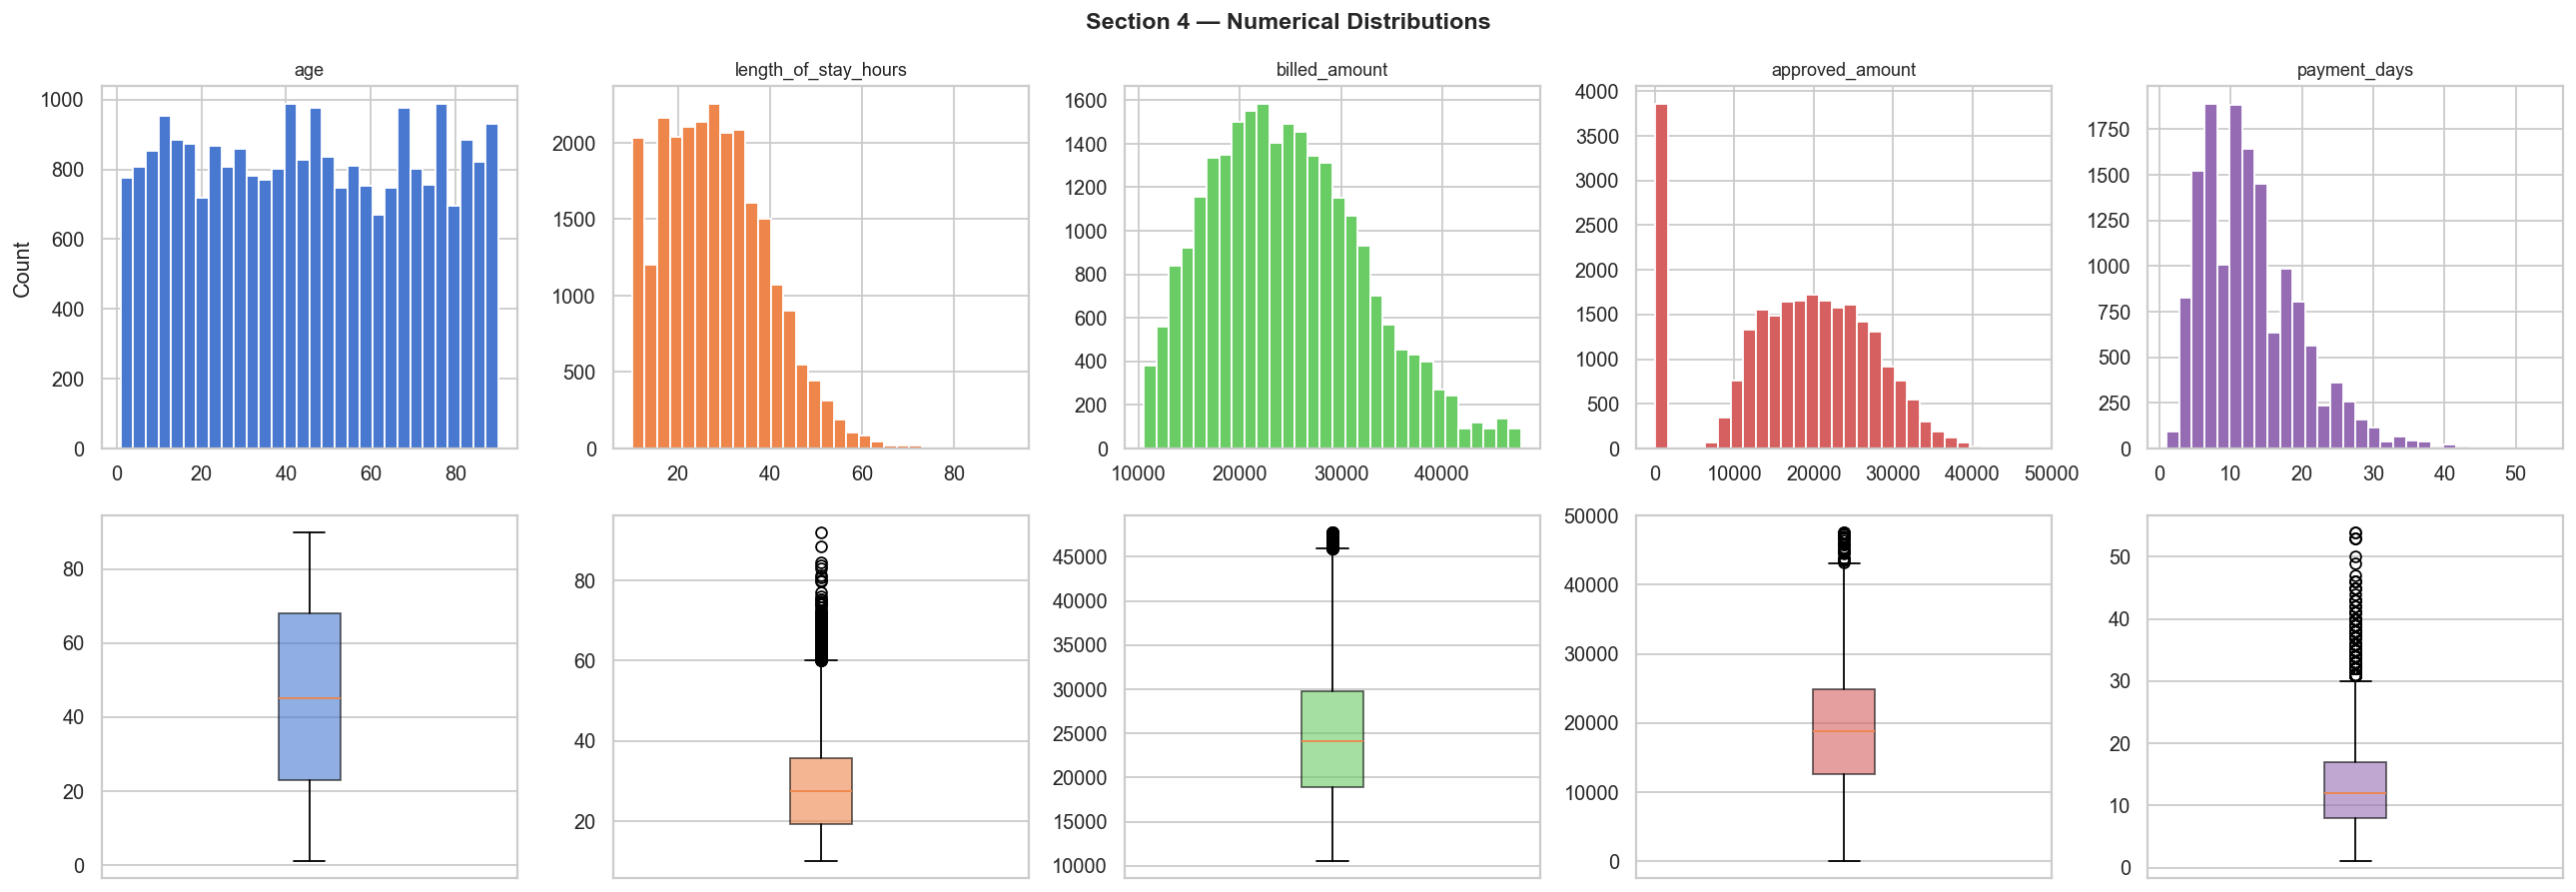

  → Saved: s4_distributions.png


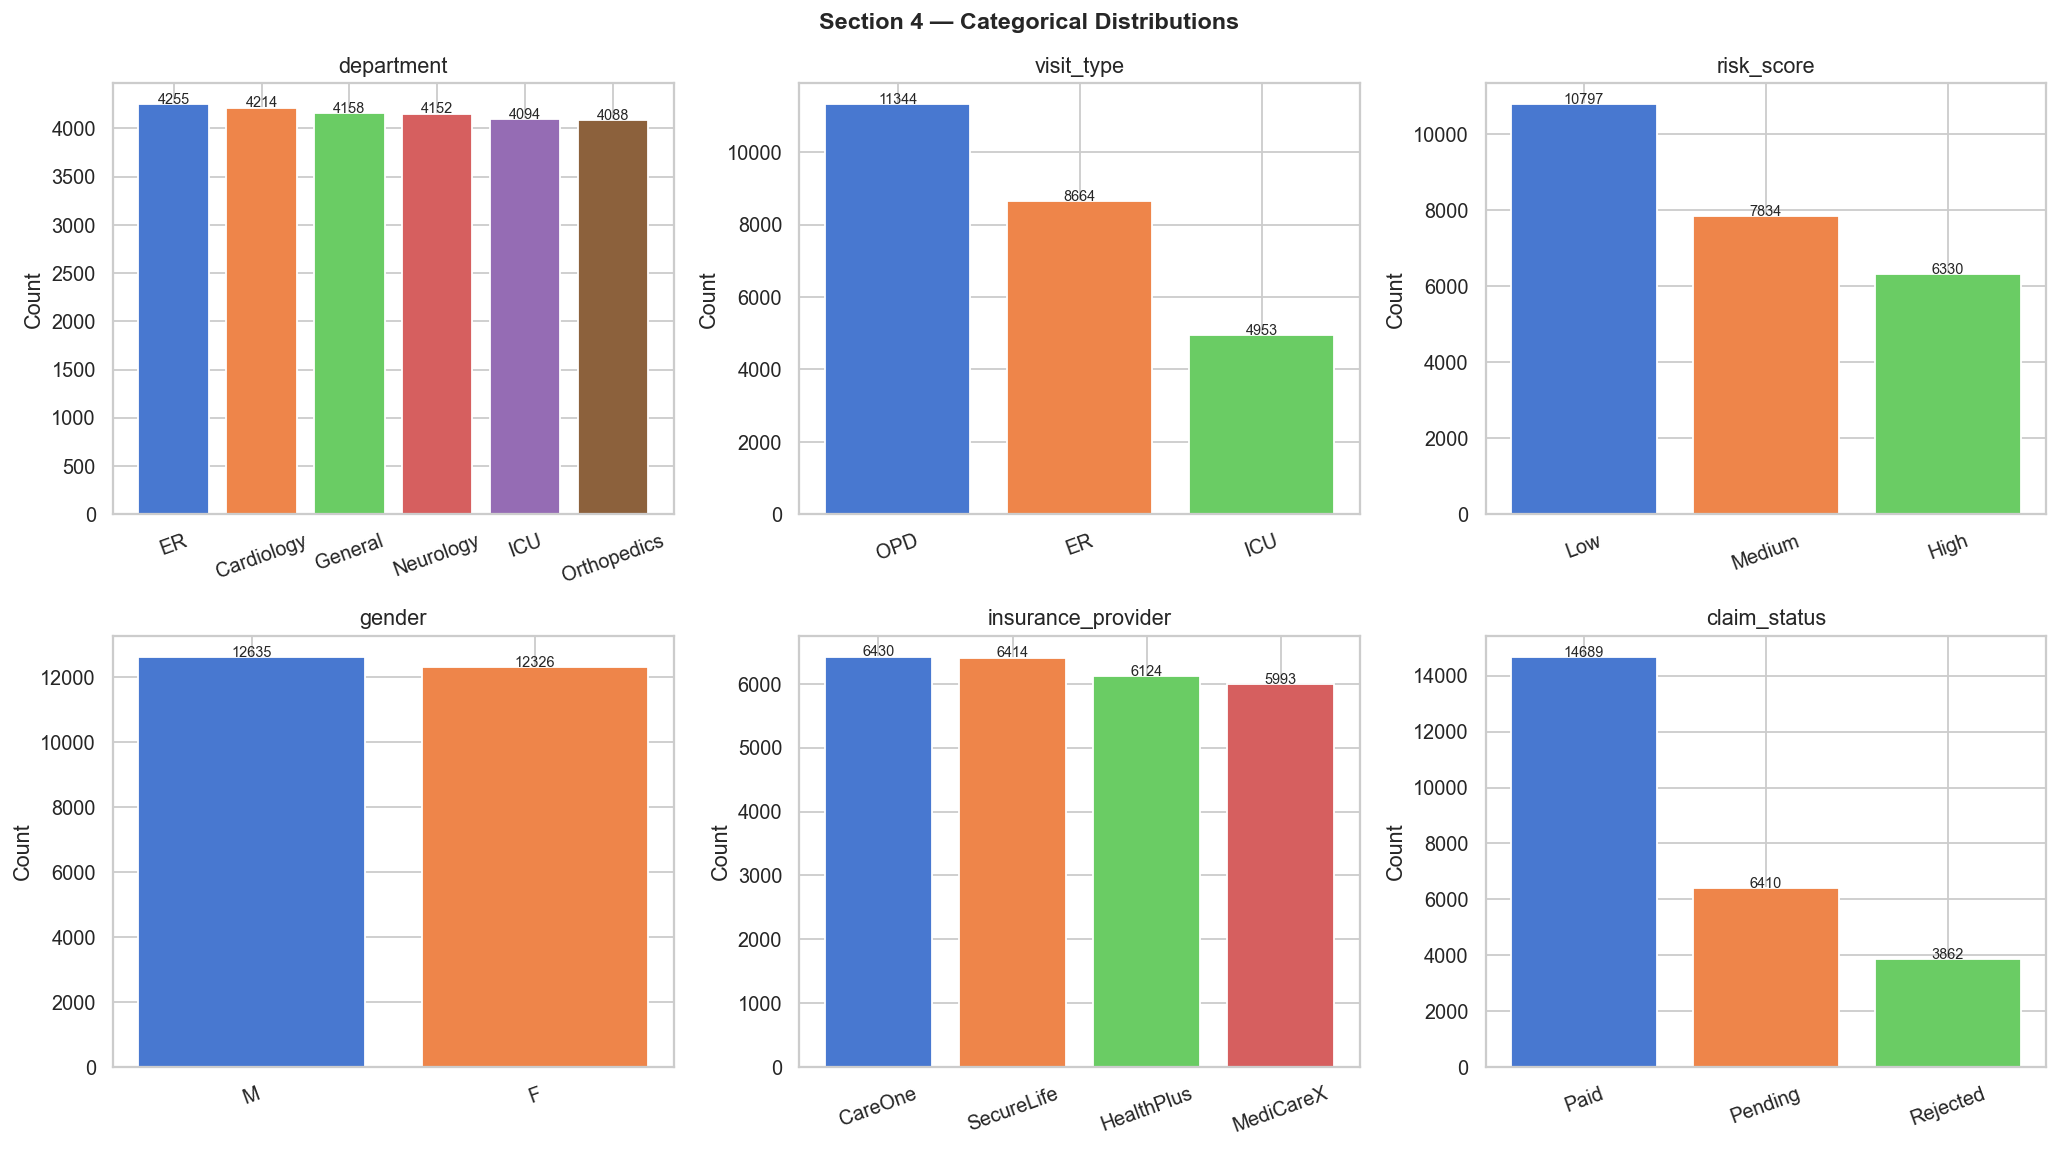

  → Saved: s4_categoricals.png


In [19]:
print("\n" + "="*60)
print("  SECTION 2 | Distribution Analysis")
print("="*60)

df = (
    visits
    .merge(patients, on="patient_id", how="left")
    .merge(billing,  on="visit_id",   how="left")
)

NUM_COLS = ["age", "length_of_stay_hours", "billed_amount",
            "approved_amount", "payment_days"]
CAT_COLS = ["department", "visit_type", "risk_score",
            "gender", "insurance_provider", "claim_status",
            "vitals_abnormal_flag"]

print("\n  Numerical summary:")
print(df[NUM_COLS].describe().round(2).to_string())

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for i, col in enumerate(NUM_COLS):
    data = df[col].dropna()
    axes[0, i].hist(data, bins=30, color=PALETTE[i % len(PALETTE)], edgecolor="white")
    axes[0, i].set_title(col, fontsize=10)
    axes[0, i].set_ylabel("Count" if i == 0 else "")
    axes[1, i].boxplot(data, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=PALETTE[i % len(PALETTE)], alpha=0.6))
    axes[1, i].set_xticks([])

plt.suptitle("Section 4 — Numerical Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("s4_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Saved: s4_distributions.png")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, CAT_COLS):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color=PALETTE[:len(vc)])
    ax.set_title(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)
    for j, v in enumerate(vc.values):
        ax.text(j, v + 5, str(v), ha="center", fontsize=8)

plt.suptitle("Section 4 — Categorical Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("s4_categoricals.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Saved: s4_categoricals.png")

# SECTION 3 — Outlier Detection


  SECTION 3 | Outlier Detection

  IQR outlier summary:
              column       Q1       Q3      IQR  lower_fence  upper_fence  outlier_count  outlier_pct
                 age    23.00    68.00    45.00       -44.50       135.50              0         0.00
length_of_stay_hours    19.38    35.67    16.29        -5.06        60.10            162         0.65
       billed_amount 18935.35 29732.92 10797.57      2738.99     45929.27            161         0.65
     approved_amount 12555.88 24842.10 12286.22     -5873.45     43271.43             25         0.10
        payment_days     8.00    17.00     9.00        -5.50        30.50            301         2.05


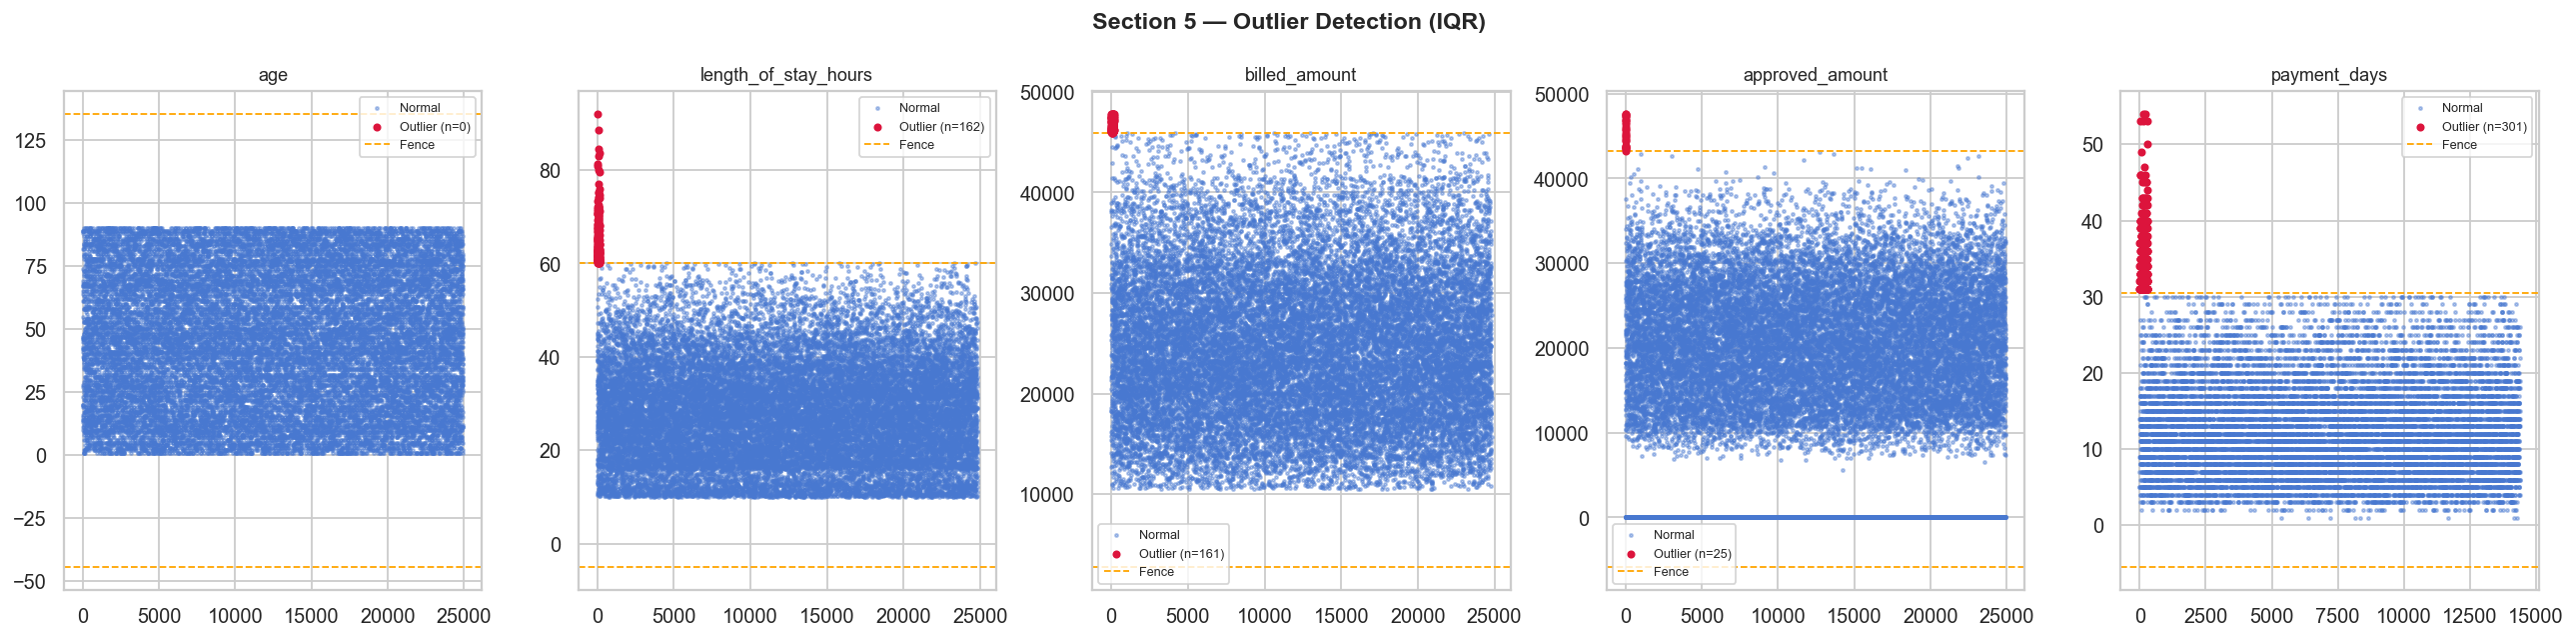

  → Saved: s5_outliers.png

  Decision: all outliers retained.
  ├─ length_of_stay_hours : extreme LOS is clinically real (ICU admissions)
  ├─ billed_amount        : high-cost procedures are valid signal
  ├─ approved_amount      : same reasoning
  └─ payment_days         : slow payers are a revenue risk signal, not errors



In [21]:
print("\n" + "="*60)
print("  SECTION 3 | Outlier Detection")
print("="*60)

outlier_report = []
for col in NUM_COLS:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    outlier_report.append({
        "column": col, "Q1": round(q1, 2), "Q3": round(q3, 2),
        "IQR": round(iqr, 2), "lower_fence": round(lo, 2),
        "upper_fence": round(hi, 2), "outlier_count": n_out,
        "outlier_pct": round(n_out / len(s) * 100, 2),
    })

out_df = pd.DataFrame(outlier_report)
print("\n  IQR outlier summary:")
print(out_df.to_string(index=False))

fig, axes = plt.subplots(1, len(NUM_COLS), figsize=(20, 5))
for ax, col in zip(axes, NUM_COLS):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    normal  = df[col][(df[col] >= lo) & (df[col] <= hi)].dropna()
    outlier = df[col][(df[col] <  lo) | (df[col] >  hi)].dropna()
    ax.scatter(range(len(normal)),  normal,  s=3, alpha=0.4,
               color=PALETTE[0], label="Normal")
    ax.scatter(range(len(outlier)), outlier, s=12, color="crimson",
               zorder=5, label=f"Outlier (n={len(outlier)})")
    ax.axhline(hi, color="orange", linestyle="--", linewidth=1, label="Fence")
    ax.axhline(lo, color="orange", linestyle="--", linewidth=1)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle("Section 5 — Outlier Detection (IQR)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("s5_outliers.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Saved: s5_outliers.png")

print("""
  Decision: all outliers retained.
  ├─ length_of_stay_hours : extreme LOS is clinically real (ICU admissions)
  ├─ billed_amount        : high-cost procedures are valid signal
  ├─ approved_amount      : same reasoning
  └─ payment_days         : slow payers are a revenue risk signal, not errors
""")

# SECTION 4 — Operational Trends & Business Insights

In [26]:
df["is_high_risk"]    = (df["risk_score"] == "High").astype(int)
df["claim_paid"]      = (df["claim_status"] == "Paid").astype(int)
df["revenue_leakage"] = df["billed_amount"] - df["approved_amount"]

print(f"  is_high_risk    : {df['is_high_risk'].sum():,} high-risk visits "
      f"({df['is_high_risk'].mean()*100:.1f}%)")
print(f"  claim_paid      : {df['claim_paid'].sum():,} paid claims "
      f"({df['claim_paid'].mean()*100:.1f}%)")
print(f"  revenue_leakage : mean ₹{df['revenue_leakage'].mean():,.0f}, "
      f"total ₹{df['revenue_leakage'].sum():,.0f}")

  is_high_risk    : 6,330 high-risk visits (25.4%)
  claim_paid      : 14,689 paid claims (58.8%)
  revenue_leakage : mean ₹6,988, total ₹174,419,686



  SECTION 4 | Operational Trends & Business Insights

  7A — Department Performance:
             visits  avg_los  high_risk_pct  avg_billed  avg_leakage
department                                                          
ER             4255    26.05           0.20    19677.83      5982.93
Cardiology     4214    32.50           0.36    28444.59      7541.83
General        4158    26.48           0.21    15286.10       157.87
Neurology      4152    26.04           0.20    26046.37      5143.29
ICU            4094    32.05           0.34    34895.48     20158.38
Orthopedics    4088    26.49           0.21    24133.96      3092.29

  7B — Insurance Provider Behaviour:
                    total_claims  paid_pct  avg_payment_days  total_billed  total_approved  approval_rate
insurance_provider                                                                                       
SecureLife                  6414      0.68             12.84  1.587498e+08    1.404882e+08           0.88
Health

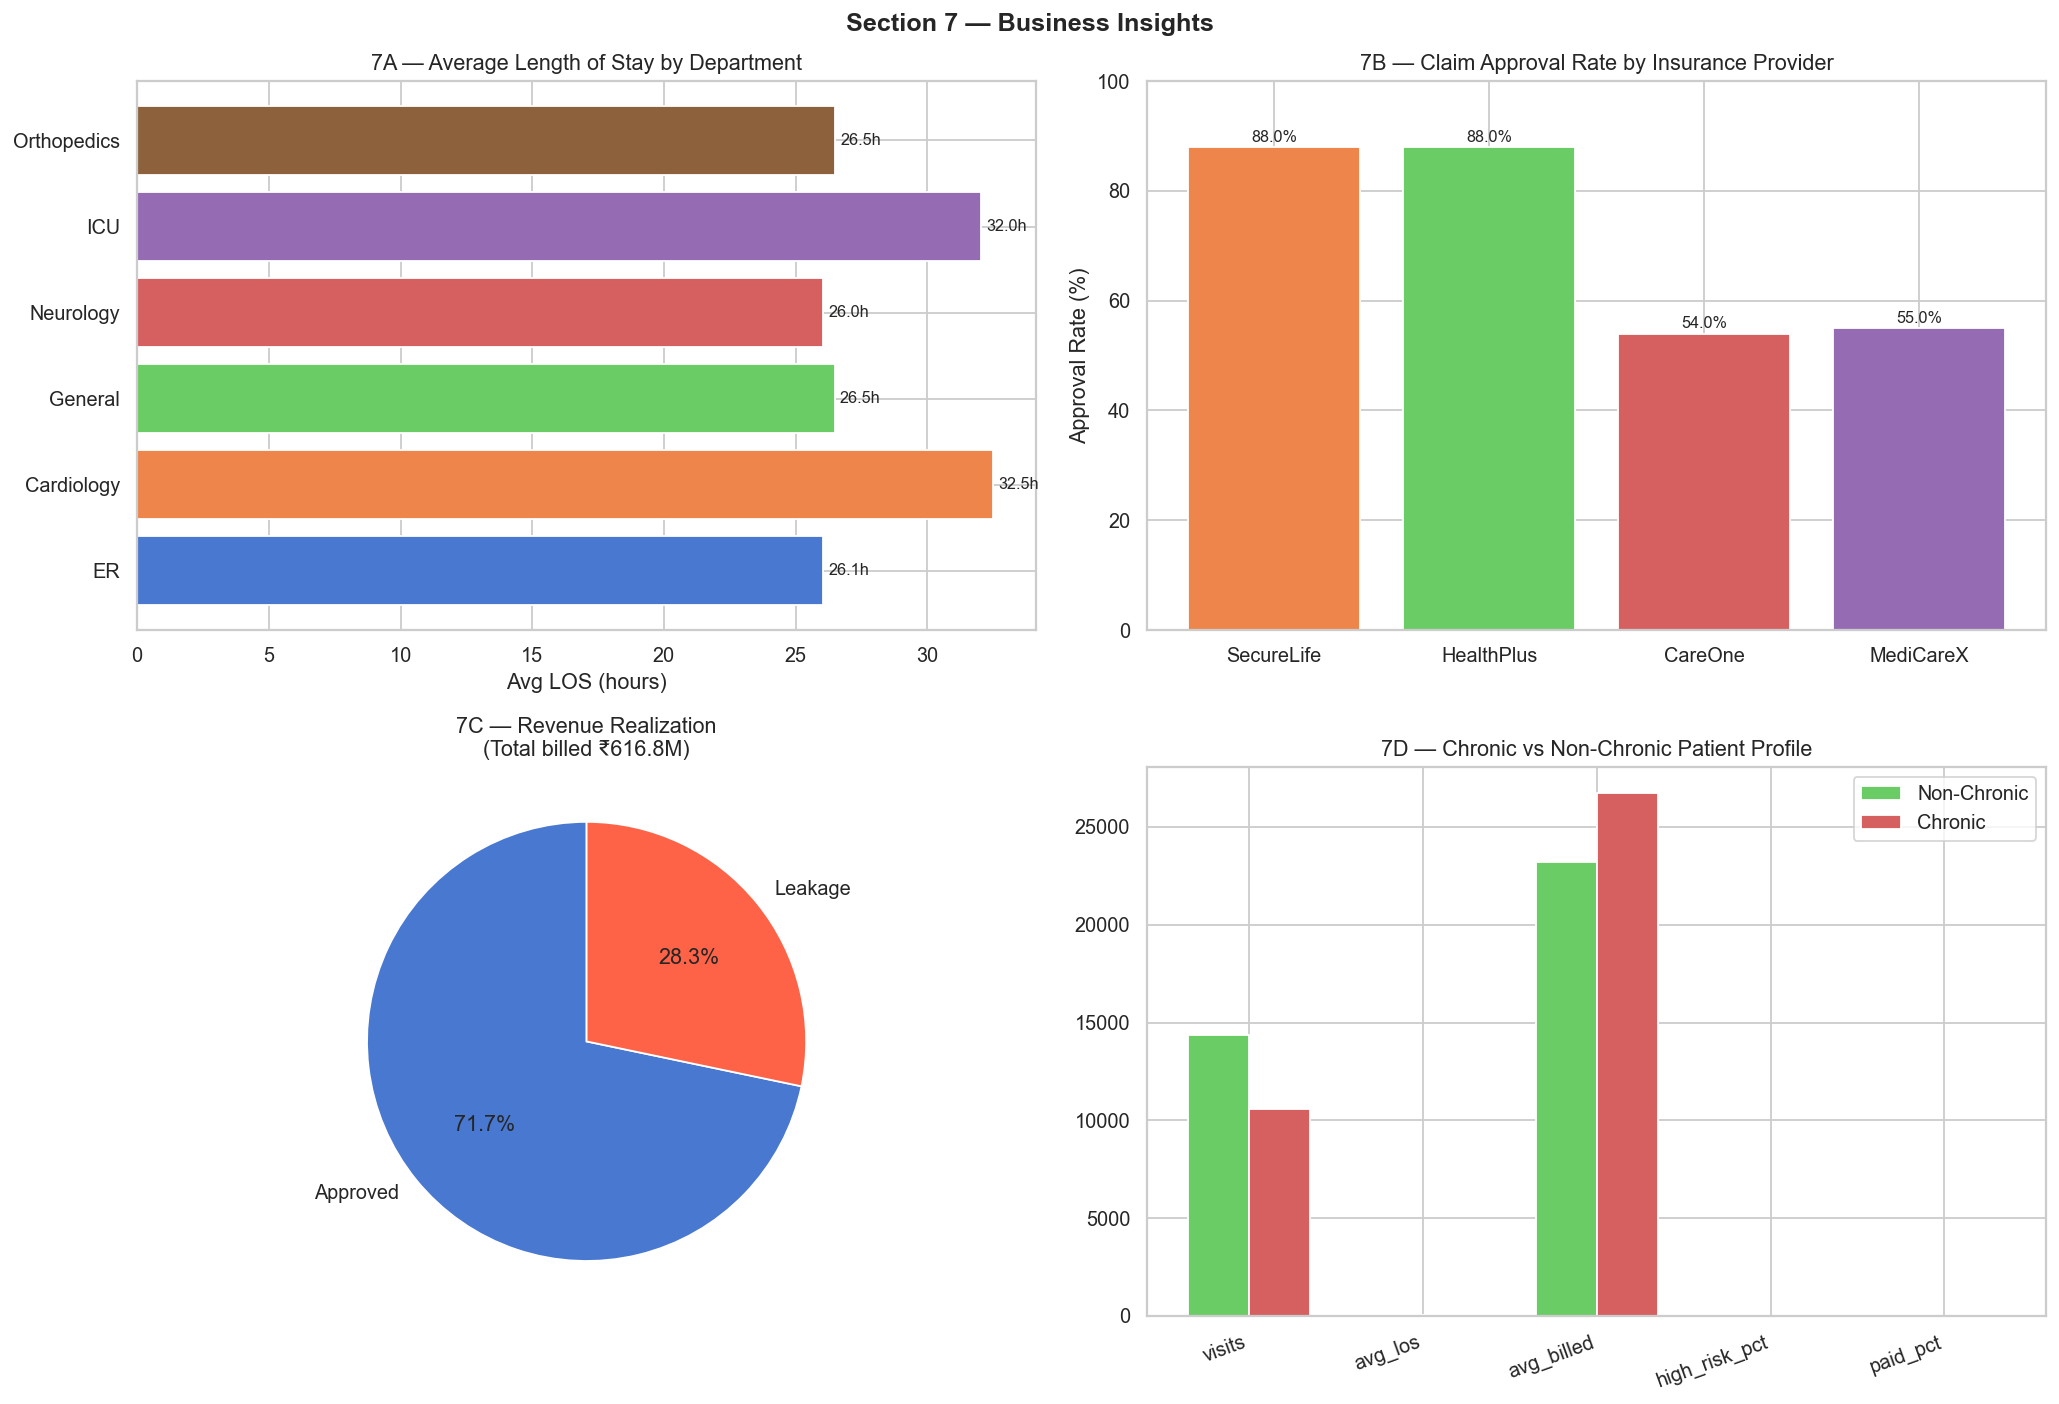

  → Saved: s7_business_insights.png


In [27]:
print("\n" + "="*60)
print("  SECTION 4 | Operational Trends & Business Insights")
print("="*60)
dept = (
    df.groupby("department").agg(
        visits        =("visit_id",             "count"),
        avg_los       =("length_of_stay_hours",  "mean"),
        high_risk_pct =("is_high_risk",          "mean"),
        avg_billed    =("billed_amount",         "mean"),
        avg_leakage   =("revenue_leakage",       "mean"),
    ).round(2).sort_values("visits", ascending=False)
)
print("\n  7A — Department Performance:")
print(dept.to_string())

ins = (
    df.groupby("insurance_provider").agg(
        total_claims    =("bill_id",         "count"),
        paid_pct        =("claim_paid",      "mean"),
        avg_payment_days=("payment_days",    "mean"),
        total_billed    =("billed_amount",   "sum"),
        total_approved  =("approved_amount", "sum"),
    )
    .assign(approval_rate=lambda x: (x["total_approved"] / x["total_billed"]).round(4))
    .round(2)
    .sort_values("paid_pct", ascending=False)
)
print("\n  7B — Insurance Provider Behaviour:")
print(ins.to_string())

total_billed   = df["billed_amount"].sum()
total_approved = df["approved_amount"].sum()
total_leakage  = df["revenue_leakage"].sum()
print(f"""
  7C — Revenue Realization:
  ├─ Total billed   : ₹{total_billed:>15,.0f}
  ├─ Total approved : ₹{total_approved:>15,.0f}
  ├─ Revenue leakage: ₹{total_leakage:>15,.0f}
  └─ Leakage rate   :  {total_leakage/total_billed*100:.1f}%
""")

chronic = (
    df.groupby("chronic_flag").agg(
        visits        =("visit_id",             "count"),
        avg_los       =("length_of_stay_hours",  "mean"),
        avg_billed    =("billed_amount",         "mean"),
        high_risk_pct =("is_high_risk",          "mean"),
        paid_pct      =("claim_paid",            "mean"),
    ).round(2)
)
chronic.index = ["Non-Chronic", "Chronic"]
print("  7D — Chronic vs Non-Chronic Patient Profile:")
print(chronic.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0, 0].barh(dept.index, dept["avg_los"], color=PALETTE)
axes[0, 0].set_xlabel("Avg LOS (hours)")
axes[0, 0].set_title("7A — Average Length of Stay by Department")
for i, v in enumerate(dept["avg_los"]):
    axes[0, 0].text(v + 0.2, i, f"{v:.1f}h", va="center", fontsize=9)

axes[0, 1].bar(ins.index, ins["approval_rate"] * 100, color=PALETTE[1:])
axes[0, 1].set_ylabel("Approval Rate (%)")
axes[0, 1].set_title("7B — Claim Approval Rate by Insurance Provider")
axes[0, 1].set_ylim(0, 100)
for i, v in enumerate(ins["approval_rate"] * 100):
    axes[0, 1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

axes[1, 0].pie(
    [total_approved, total_leakage],
    labels=["Approved", "Leakage"],
    autopct="%1.1f%%",
    colors=[PALETTE[0], "tomato"],
    startangle=90,
    wedgeprops=dict(edgecolor="white")
)
axes[1, 0].set_title(f"7C — Revenue Realization\n(Total billed ₹{total_billed/1e6:.1f}M)")

x = np.arange(len(chronic.columns))
w = 0.35
axes[1, 1].bar(x - w/2, chronic.iloc[0], w, label="Non-Chronic", color=PALETTE[2])
axes[1, 1].bar(x + w/2, chronic.iloc[1], w, label="Chronic",     color=PALETTE[3])
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(chronic.columns, rotation=20, ha="right")
axes[1, 1].set_title("7D — Chronic vs Non-Chronic Patient Profile")
axes[1, 1].legend()

plt.suptitle("Section 7 — Business Insights", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("s7_business_insights.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Saved: s7_business_insights.png")

# SECTION 5 — Correlation & Risk Analysis

In [32]:
df["approval_rate"] = df["approved_amount"] / df["billed_amount"]
df["days_to_visit"] = (df["visit_date"] - df["registration_date"]).dt.days


  SECTION 5 | Correlation % Risk Analysis


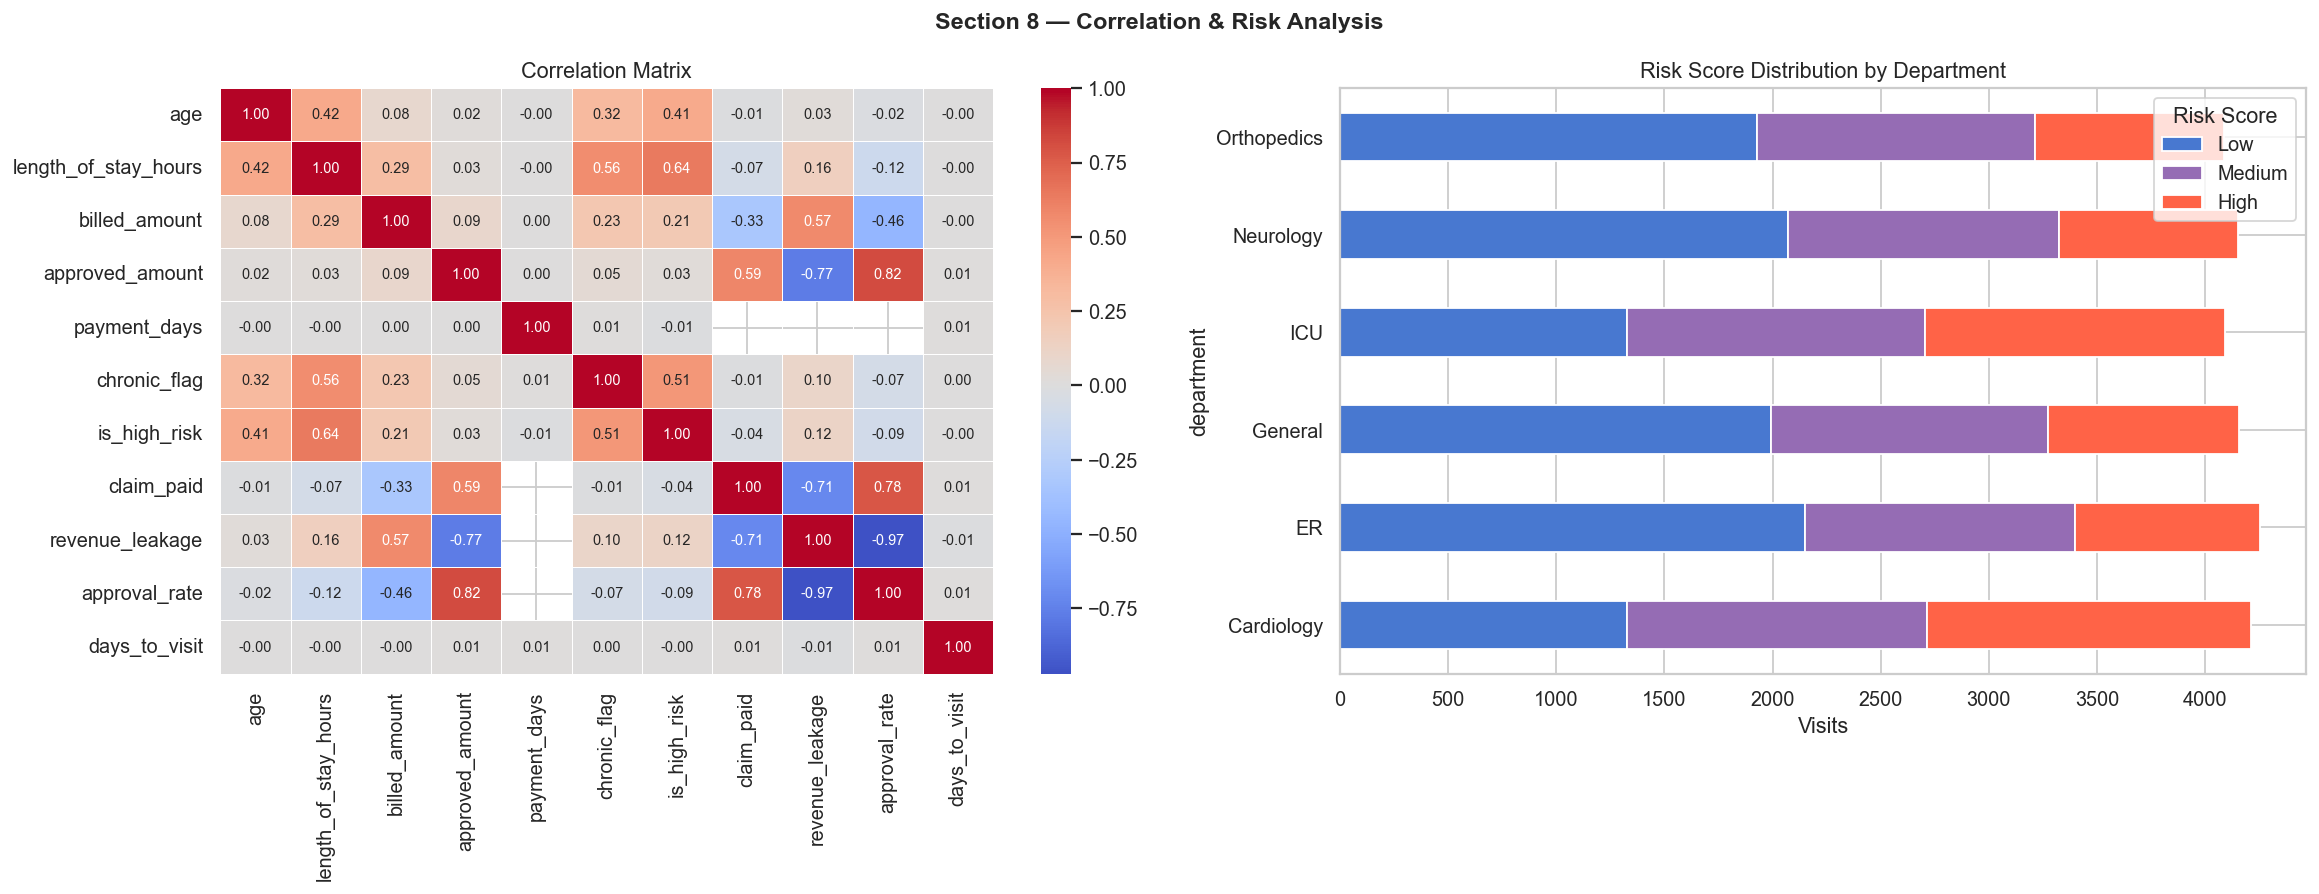

  → Saved: s8_correlation_risk.png

  Notable correlations (|r| ≥ 0.30):
      feature_a            feature_b  corr
  approval_rate      revenue_leakage -0.97
  approval_rate      approved_amount  0.82
  approval_rate           claim_paid  0.78
approved_amount      revenue_leakage -0.77
     claim_paid      revenue_leakage -0.71
   is_high_risk length_of_stay_hours  0.64
approved_amount           claim_paid  0.59
  billed_amount      revenue_leakage  0.57
   chronic_flag length_of_stay_hours  0.56
   chronic_flag         is_high_risk  0.51
  approval_rate        billed_amount -0.46
            age length_of_stay_hours  0.42
            age         is_high_risk  0.41
  billed_amount           claim_paid -0.33
            age         chronic_flag  0.32


In [33]:
print("\n" + "="*60)
print("  SECTION 5 | Correlation % Risk Analysis")
print("="*60)

corr_cols = ["age", "length_of_stay_hours", "billed_amount", "approved_amount",
             "payment_days", "chronic_flag", "is_high_risk", "claim_paid",
             "revenue_leakage", "approval_rate", "days_to_visit"]
corr_matrix = df[corr_cols].corr().round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=axes[0], annot_kws={"size": 8})
axes[0].set_title("Correlation Matrix")

risk_dept = (
    df.groupby(["department", "risk_score"])["visit_id"]
    .count().unstack(fill_value=0)[["Low", "Medium", "High"]]
)
risk_dept.plot(kind="barh", stacked=True, ax=axes[1],
               color=[PALETTE[0], PALETTE[4], "tomato"])
axes[1].set_xlabel("Visits")
axes[1].set_title("Risk Score Distribution by Department")
axes[1].legend(title="Risk Score")

plt.suptitle("Section 8 — Correlation & Risk Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("s8_correlation_risk.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → Saved: s8_correlation_risk.png")

notable = (
    corr_matrix.unstack().reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "corr"})
    .query("feature_a < feature_b and abs(corr) >= 0.3")
    .sort_values("corr", key=abs, ascending=False)
)
print("\n  Notable correlations (|r| ≥ 0.30):")
print(notable.to_string(index=False))

# SECTION 6 — EDA Summary & Modelling Readiness

In [35]:
raw_len = len(visits_syn)  # no rows removed — synthetic data is clean by construction

new_features = ["is_high_risk", "claim_paid", "revenue_leakage",
                 "approval_rate", "days_to_visit"]

In [36]:
print("\n" + "="*60)
print("  SECTION 6 | EDA Summary & Modelling Readiness")
print("="*60)

print(f"""
  Dataset
  ├─ Raw records (from DB) : {raw_len:,} visits
  ├─ After DQ cleaning     : {len(df):,} visits  ({raw_len - len(df):,} removed)
  ├─ Features              : {df.shape[1]} columns  ({len(new_features)} engineered)
  └─ Date range            : {df['visit_date'].min().date()} → {df['visit_date'].max().date()}

  Key Business Findings
  ├─ Revenue leakage       : {total_leakage/total_billed*100:.1f}%  (₹{total_leakage/1e6:.1f}M of ₹{total_billed/1e6:.1f}M billed)
  ├─ Rejected + Pending    : {(df['claim_status'].isin(['Rejected','Pending'])).mean()*100:.1f}% of all claims
  ├─ High-risk visits      : {df['is_high_risk'].mean()*100:.1f}% of all visits
  └─ Chronic patients show higher avg LOS and billed amounts

  Modelling Readiness
  ├─ Model A — Visit Risk Classification
  │    Target  : risk_score  (Low / Medium / High)
  │    Features: age, chronic_flag, department, visit_type,
  │              los_band, age_group, doctor_id, visit_month
  └─ Model B — Claim Outcome Classification
       Target  : claim_status  (Paid / Pending / Rejected)
       Features: insurance_provider, billed_amount, approved_amount,
                 approval_rate, payment_days, department,
                 risk_score, chronic_flag, visit_type
""")

print("  Phase 2 EDA complete.\n")


  SECTION 6 | EDA Summary & Modelling Readiness

  Dataset
  ├─ Raw records (from DB) : 24,961 visits
  ├─ After DQ cleaning     : 24,961 visits  (0 removed)
  ├─ Features              : 26 columns  (5 engineered)
  └─ Date range            : 2025-01-20 → 2026-04-12

  Key Business Findings
  ├─ Revenue leakage       : 28.3%  (₹174.4M of ₹616.8M billed)
  ├─ Rejected + Pending    : 41.2% of all claims
  ├─ High-risk visits      : 25.4% of all visits
  └─ Chronic patients show higher avg LOS and billed amounts

  Modelling Readiness
  ├─ Model A — Visit Risk Classification
  │    Target  : risk_score  (Low / Medium / High)
  │    Features: age, chronic_flag, department, visit_type,
  │              los_band, age_group, doctor_id, visit_month
  └─ Model B — Claim Outcome Classification
       Target  : claim_status  (Paid / Pending / Rejected)
       Features: insurance_provider, billed_amount, approved_amount,
                 approval_rate, payment_days, department,
                 r

# Section-7: BIVARIATE ANALYSIS

In [37]:
OUTPUT_DIR = Path("eda_plots")
PLOT_DIR = Path("Bivariate Analysis")

OUTPUT_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

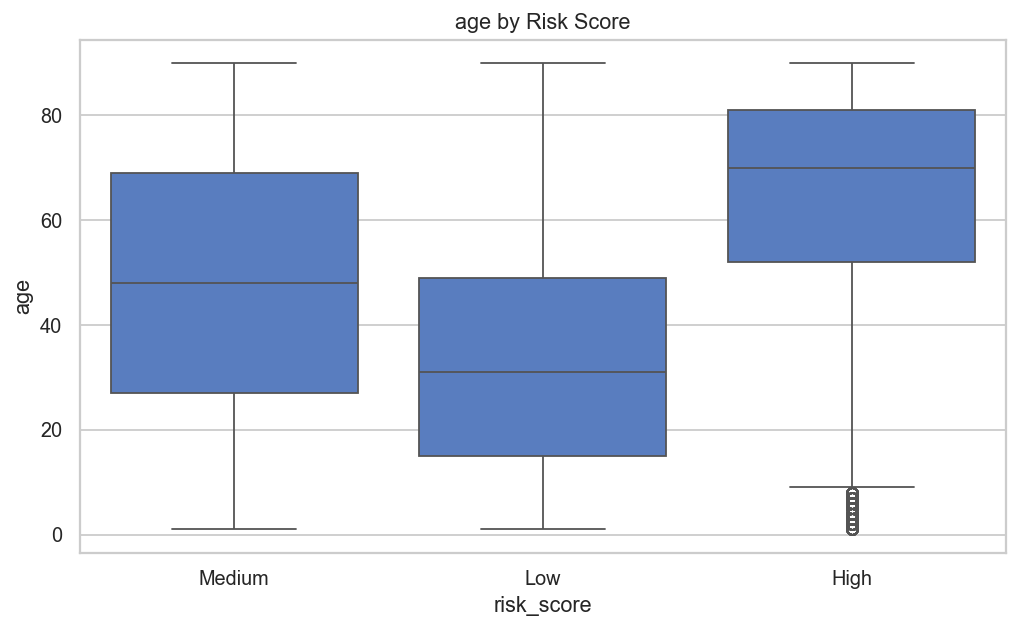

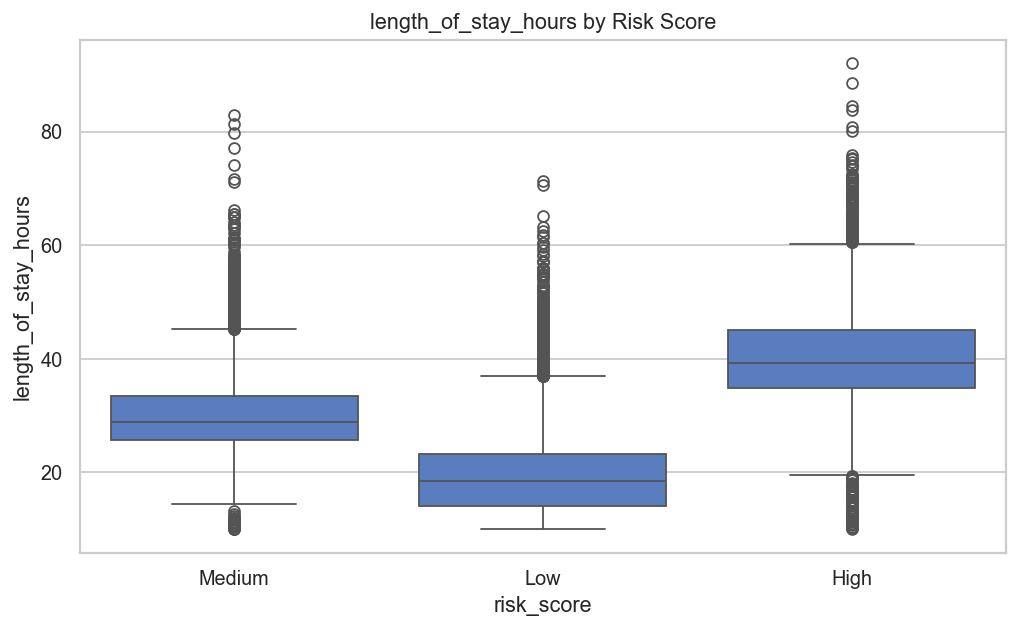

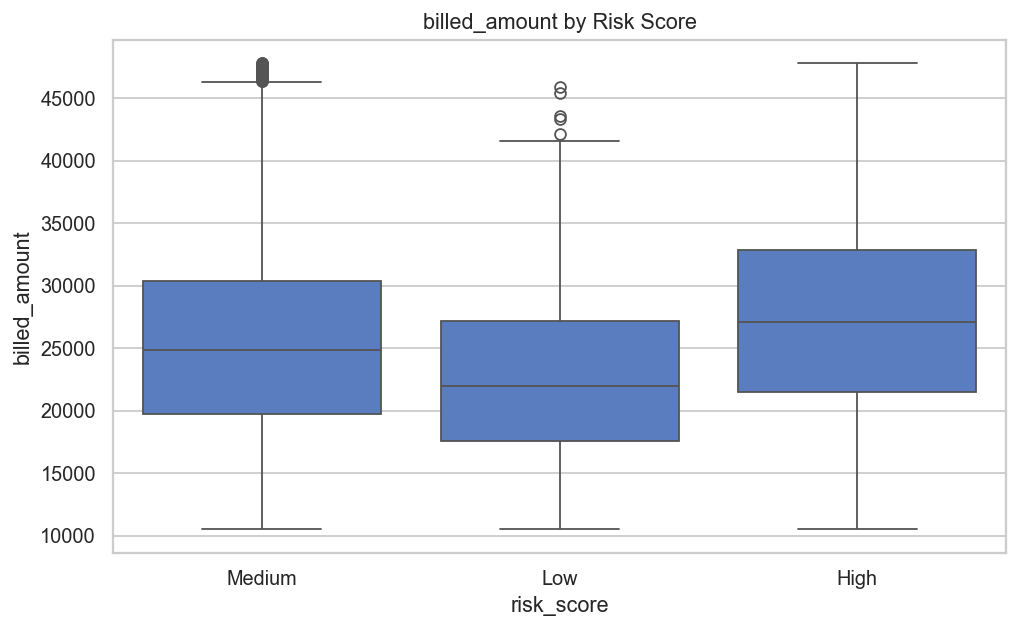

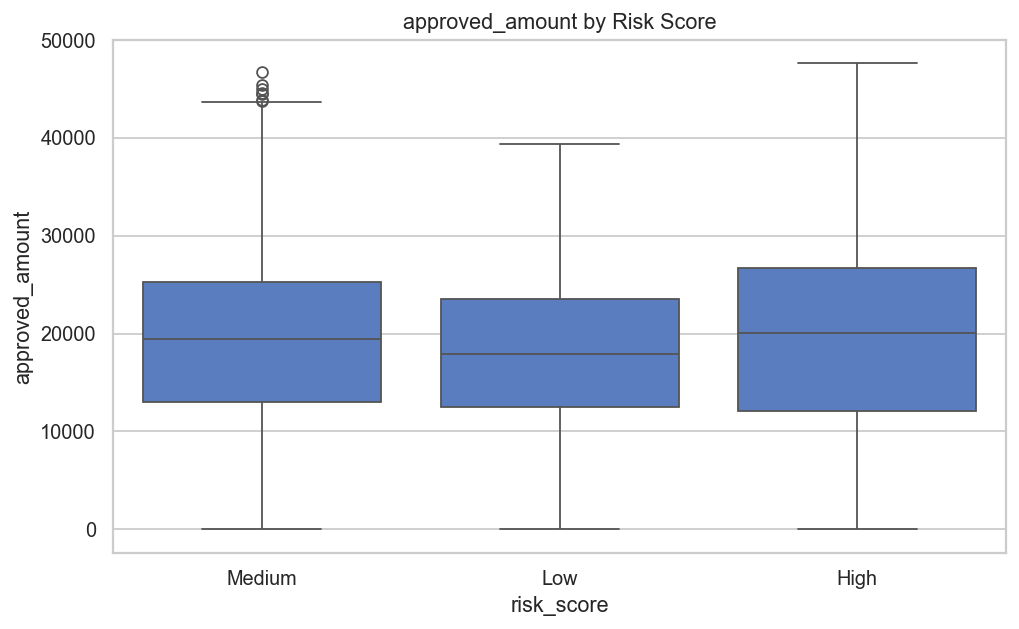

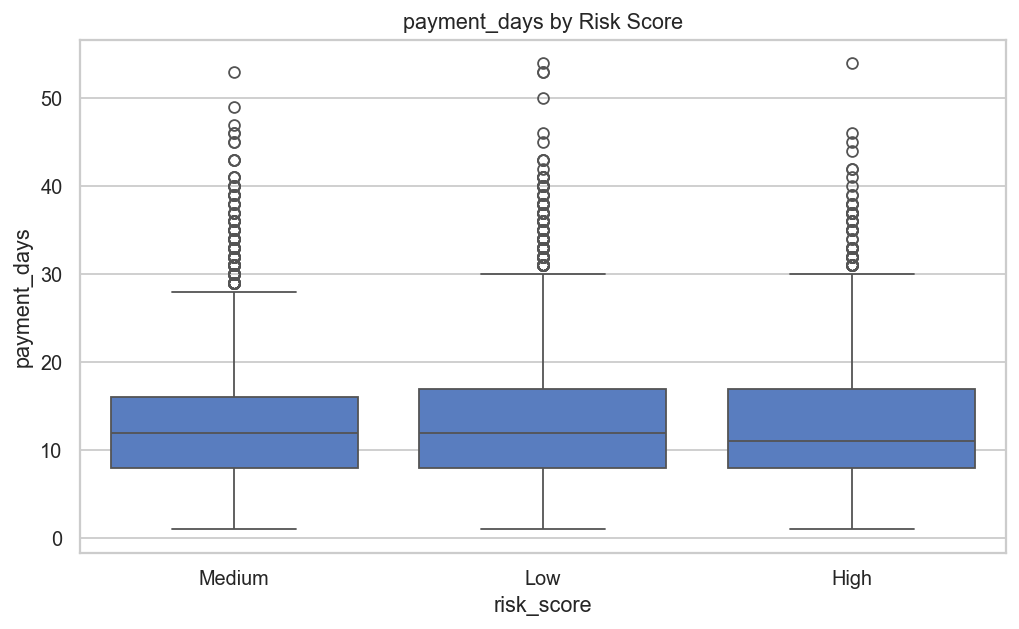

risk_score,High,Low,Medium
department,,,
Cardiology,0.356,0.314,0.330
ER,0.202,0.506,0.293
General,0.212,0.479,0.308
ICU,0.339,0.324,0.337
Neurology,0.199,0.499,0.302
Orthopedics,0.214,0.472,0.314


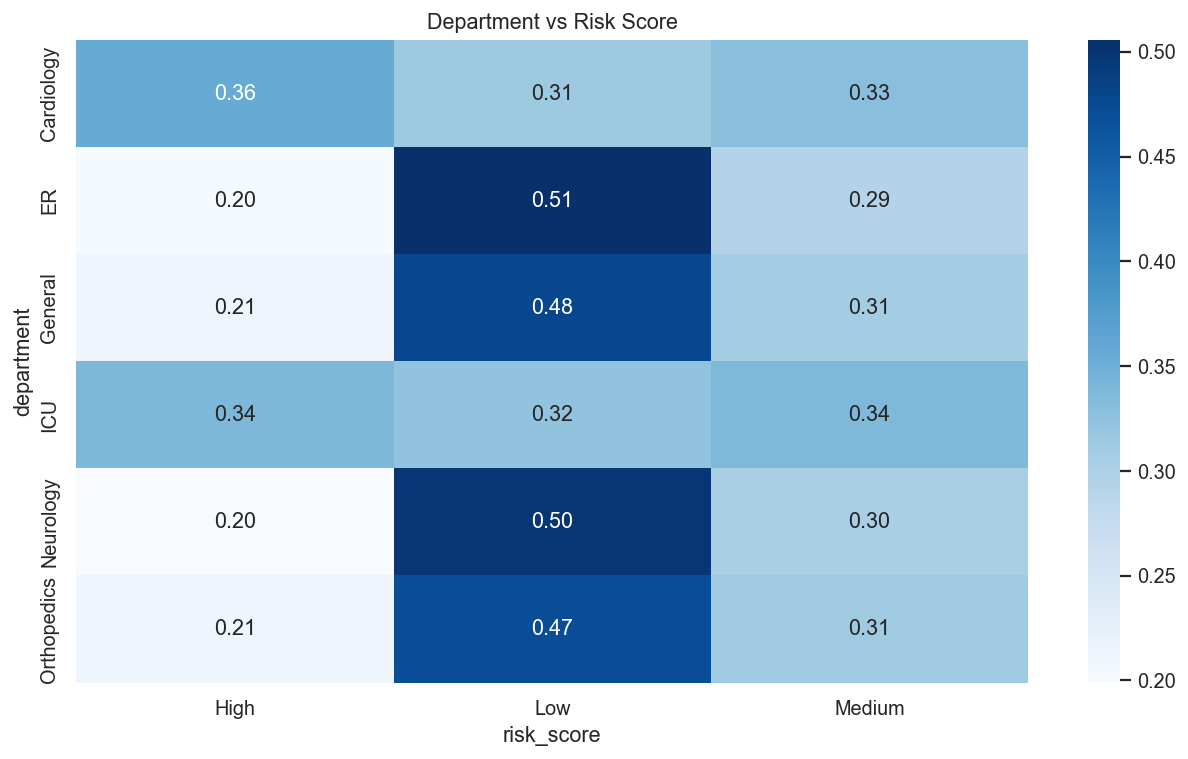

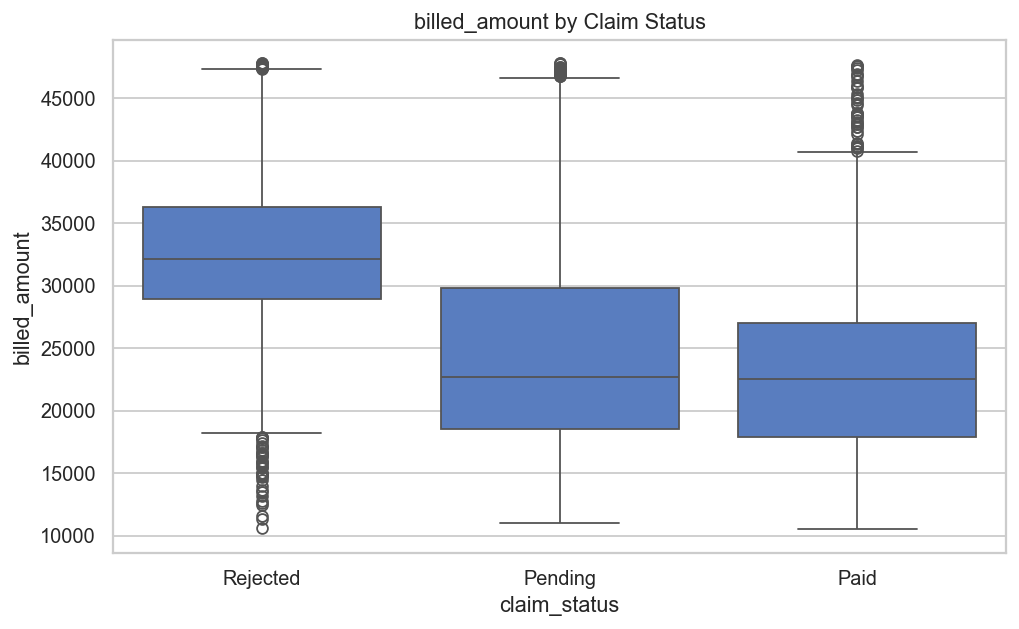

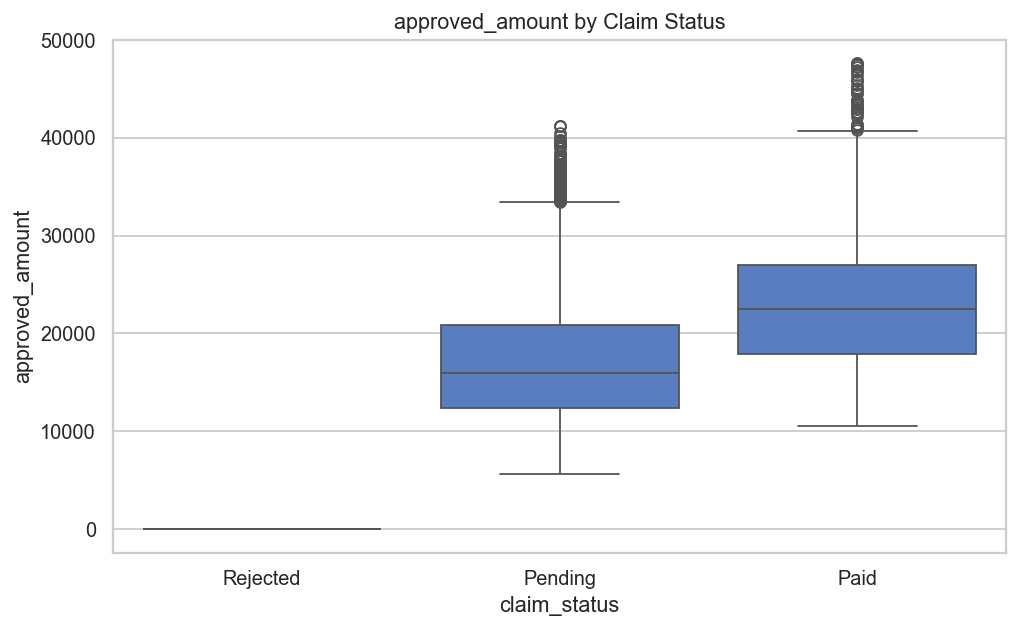

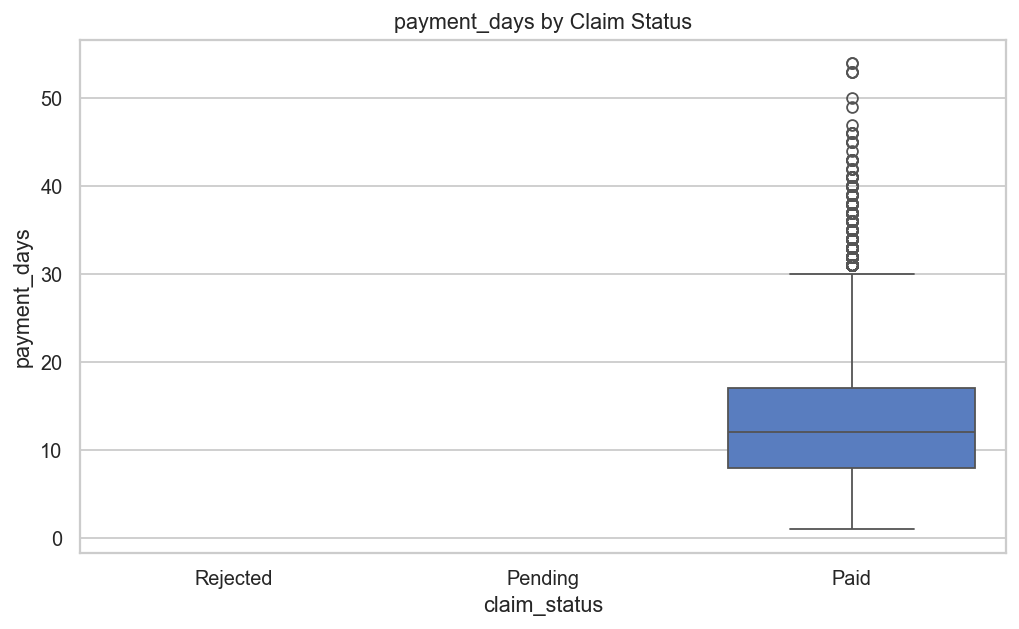

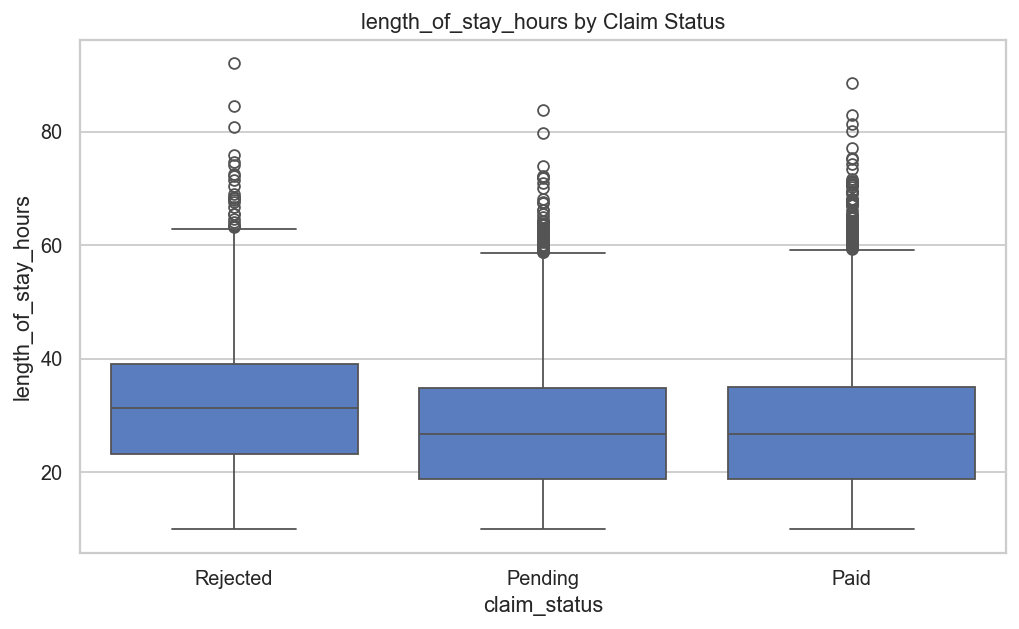

claim_status,Paid,Pending,Rejected
department,,,
Cardiology,0.756,0.009,0.236
ER,0.056,0.921,0.023
General,0.985,0.006,0.008
ICU,0.037,0.574,0.390
Neurology,0.822,0.009,0.170
Orthopedics,0.882,0.011,0.107


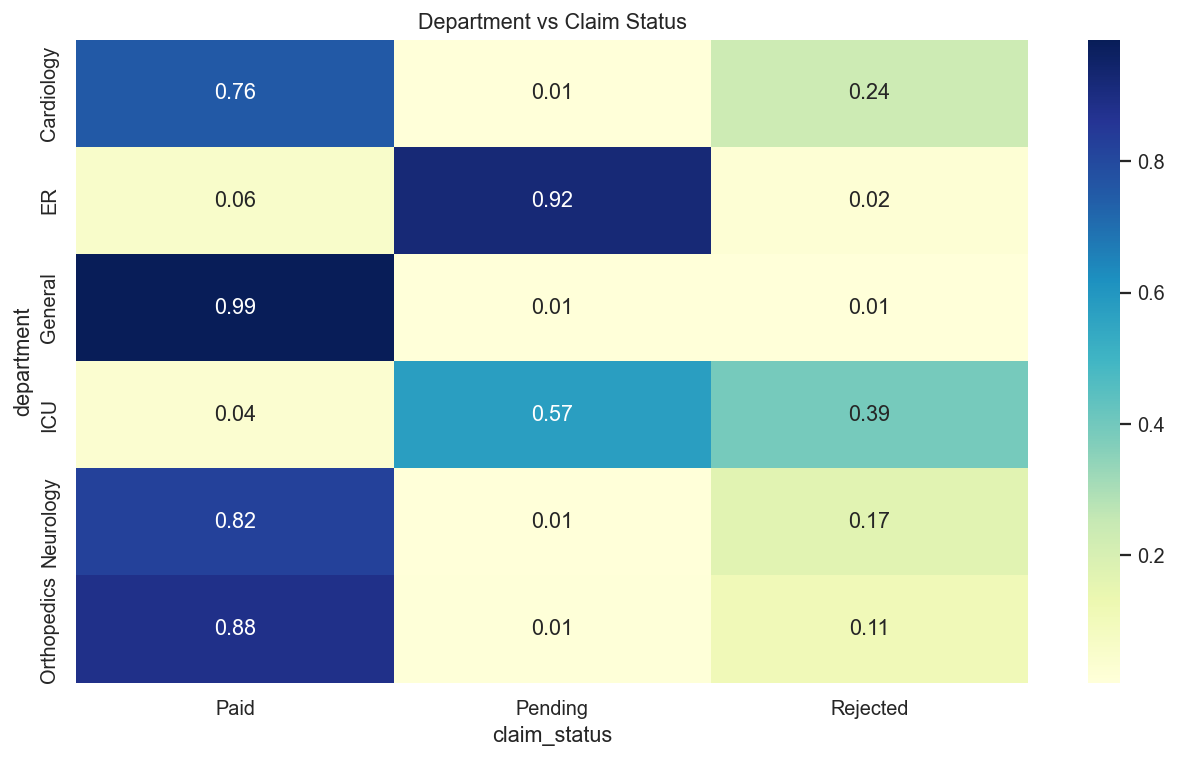

claim_status,Paid,Pending,Rejected
insurance_provider,,,
CareOne,0.499,0.198,0.303
HealthPlus,0.669,0.316,0.015
MediCareX,0.500,0.207,0.293
SecureLife,0.684,0.305,0.010


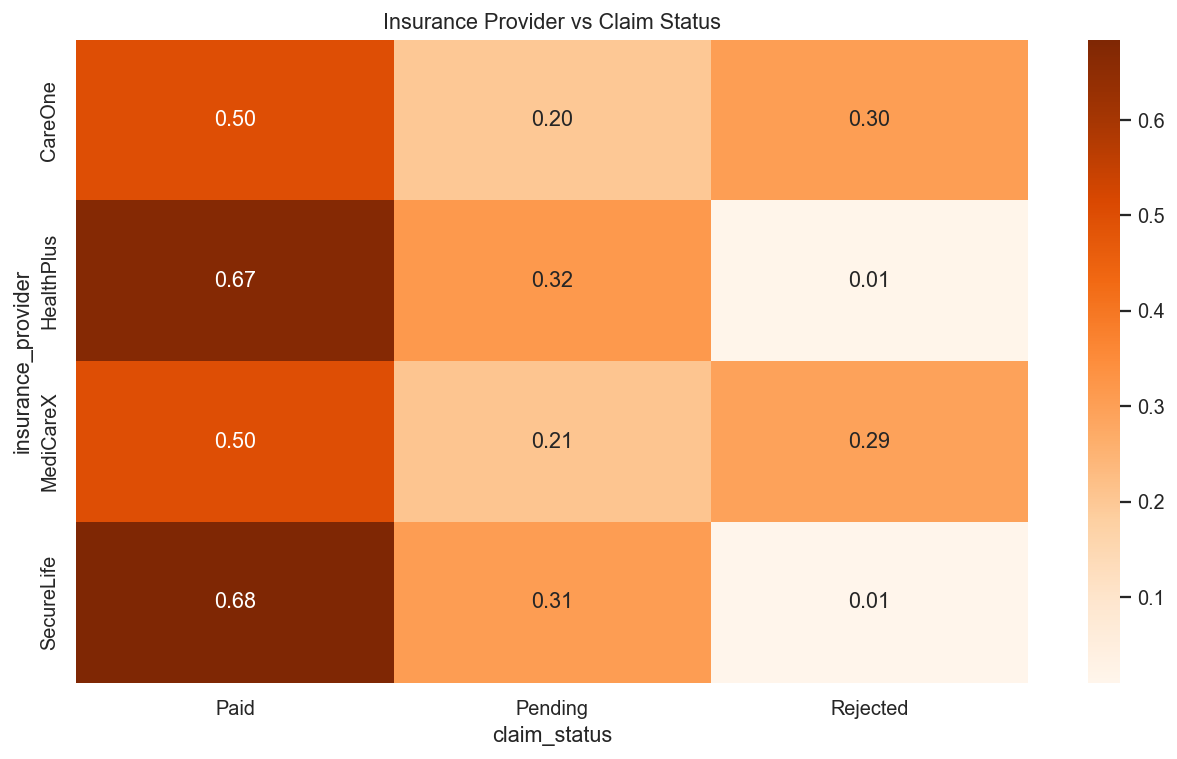

In [38]:
# ============================================================
# Risk Score Relationships
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

risk_features = [
    "age",
    "length_of_stay_hours",
    "billed_amount",
    "approved_amount",
    "payment_days"
]

for col in risk_features:

    if col not in df.columns:
        continue

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="risk_score",
        y=col
    )

    plt.title(f"{col} by Risk Score")

    plt.tight_layout()

    plt.savefig(
        PLOT_DIR / f"riskscore_{col}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()
# ============================================================
# Risk Score Distribution by Department
# ============================================================

risk_department = pd.crosstab(
    df["department"],
    df["risk_score"],
    normalize="index"
)

display(risk_department.round(3))

plt.figure(figsize=(10,6))

sns.heatmap(
    risk_department,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Department vs Risk Score")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "department_vs_riskscore.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()
# ============================================================
# Claim Status Relationships
# ============================================================

claim_features = [
    "billed_amount",
    "approved_amount",
    "payment_days",
    "length_of_stay_hours"
]

for col in claim_features:

    if col not in df.columns:
        continue

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="claim_status",
        y=col
    )

    plt.title(f"{col} by Claim Status")

    plt.tight_layout()

    plt.savefig(
        PLOT_DIR / f"claimstatus_{col}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

claim_department = pd.crosstab(
    df["department"],
    df["claim_status"],
    normalize="index"
)

display(claim_department.round(3))

plt.figure(figsize=(10,6))

sns.heatmap(
    claim_department,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Department vs Claim Status")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "department_vs_claimstatus.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

provider_claims = pd.crosstab(
    df["insurance_provider"],
    df["claim_status"],
    normalize="index"
)

display(provider_claims.round(3))

plt.figure(figsize=(10,6))

sns.heatmap(
    provider_claims,
    annot=True,
    fmt=".2f",
    cmap="Oranges"
)

plt.title("Insurance Provider vs Claim Status")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "insurance_vs_claimstatus.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()
